<a href="https://colab.research.google.com/github/MohammadHammoudeh14/car_price_prediction/blob/main/Car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import the dependencies

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder,OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn import set_config
set_config(transform_output='pandas')

In [31]:
def regression_metrics(y_true, y_pred, label='', verbose = True, output_dict=False):
  # Get metrics
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = np.sqrt(mse)
  r_squared = r2_score(y_true, y_pred)
  if verbose == True:
    # Print Result with Label and Header
    header = "-"*60
    print(header, f"Regression Metrics: {label}", header, sep='\n')
    print(f"- MAE = {mae:,.3f}")
    print(f"- MSE = {mse:,.3f}")
    print(f"- RMSE = {rmse:,.3f}")
    print(f"- R^2 = {r_squared:,.3f}")
  if output_dict == True:
      metrics = {'Label':label, 'MAE':mae,
                 'MSE':mse, 'RMSE':rmse, 'R^2':r_squared}
      return metrics

def evaluate_regression(reg, X_train, y_train, X_test, y_test, verbose = True,
                        output_frame=False):
  # Get predictions for training data
  y_train_pred = reg.predict(X_train)

  # Call the helper function to obtain regression metrics for training data
  results_train = regression_metrics(y_train, y_train_pred, verbose = verbose,
                                     output_dict=output_frame,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = reg.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = regression_metrics(y_test, y_test_pred, verbose = verbose,
                                  output_dict=output_frame,
                                    label='Test Data' )

  # Store results in a dataframe if ouput_frame is True
  if output_frame:
    results_df = pd.DataFrame([results_train,results_test])
    # Set the label as the index
    results_df = results_df.set_index('Label')
    # Set index.name to none to get a cleaner looking result
    results_df.index.name=None
    # Return the dataframe
    return results_df.round(3)

Data collection and processing

In [32]:
path ='/content/drive/MyDrive/Data /car data.csv'
df = pd.read_csv(path)
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [33]:
# checking the number of rows and columns
df.shape

(301, 9)

In [34]:
# Getting some information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [35]:
# checking the number of missing values
df.isna().sum().sum()

np.int64(0)

In [36]:
# check the object columns
df_columns = df.select_dtypes('object').head()
for i in df_columns:
  print(f'values count for {i}')
  print(df[i].value_counts())
  print('\n')

values count for Car_Name
Car_Name
city                  26
corolla altis         16
verna                 14
fortuner              11
brio                  10
                      ..
Honda Activa 125       1
Hero Hunk              1
Hero  Ignitor Disc     1
Hero  CBZ Xtreme       1
Bajaj  ct 100          1
Name: count, Length: 98, dtype: int64


values count for Fuel_Type
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64


values count for Seller_Type
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64


values count for Transmission
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64




Splitting the data to train and test

In [37]:
y = df['Selling_Price']
X = df.drop(columns=['Selling_Price','Car_Name'],axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.1 ,random_state=42)

In [38]:
num_cols = X_train.select_dtypes("number").columns
print('Numeric Columns:', num_cols)
impute_mode = SimpleImputer(strategy='most_frequent')
scaler = StandardScaler()
num_pipe = make_pipeline(impute_mode, scaler)
num_tuple = ('numeric', num_pipe, num_cols)
num_tuple

Numeric Columns: Index(['Year', 'Present_Price', 'Kms_Driven', 'Owner'], dtype='object')


('numeric',
 Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                 ('standardscaler', StandardScaler())]),
 Index(['Year', 'Present_Price', 'Kms_Driven', 'Owner'], dtype='object'))

In [39]:
ohe_cols = X_train.select_dtypes('object').columns
print("OneHotEncoder Columns:", ohe_cols)
impute_na = SimpleImputer(strategy='constant', fill_value = "NA")
ohe_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_pipe = make_pipeline(impute_na, ohe_encoder)
ohe_tuple = ('categorical', ohe_pipe, ohe_cols)
ohe_tuple

OneHotEncoder Columns: Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object')


('categorical',
 Pipeline(steps=[('simpleimputer',
                  SimpleImputer(fill_value='NA', strategy='constant')),
                 ('onehotencoder',
                  OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
 Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))

In [40]:
preprocessor = ColumnTransformer(transformers=[num_tuple,ohe_tuple],verbose_feature_names_out=False)
preprocessor


ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['Year', 'Present_Price', 'Kms_Driven', 'Owner'], dtype='object')),
                                ('categorical',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='NA',
                                                                strategy='constant')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))],
                  verbose_feature_names_out=False)

In [41]:
print(X.shape,X_train.shape,X_test.shape)

(301, 7) (270, 7) (31, 7)


Model training

In [42]:
# Loading the linear regression model
model = LinearRegression()

In [43]:
model_pipe =  make_pipeline(preprocessor,model)
model_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Year', 'Present_Price', 'Kms_Driven', 'Owner'], dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='NA',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('linearregression', LinearRegression())])

Model evaluation

In [44]:
evaluate_regression(model_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 1.212
- MSE = 3.079
- RMSE = 1.755
- R^2 = 0.886

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 1.051
- MSE = 2.673
- RMSE = 1.635
- R^2 = 0.821


Visualize the actual price and prediction

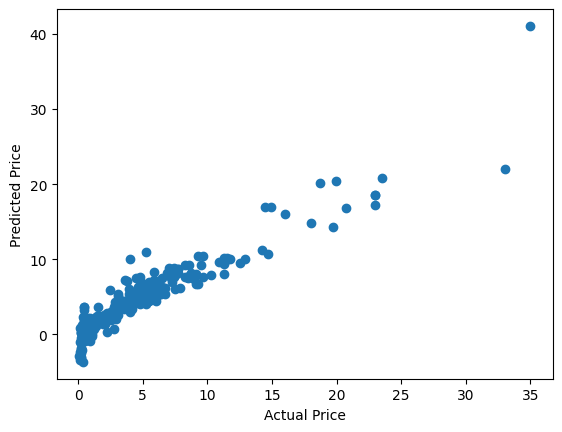

In [45]:
plt.scatter(y_train, model_pipe.predict(X_train))
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price');

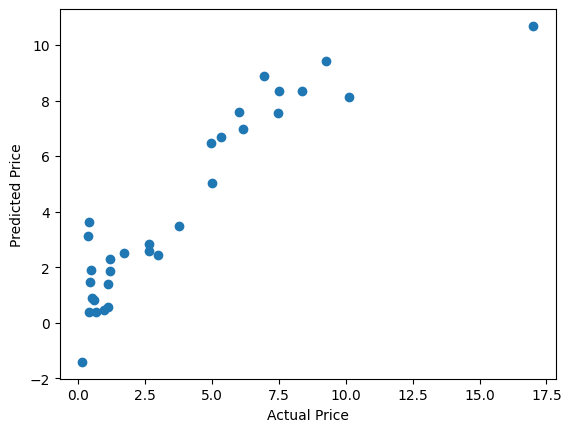

In [46]:
plt.scatter(y_test, model_pipe.predict(X_test))
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price');

Lasso Regression

In [47]:
lasso_model = Lasso()

In [48]:
lasso_pipe =  make_pipeline(preprocessor,lasso_model)
lasso_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Year', 'Present_Price', 'Kms_Driven', 'Owner'], dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='NA',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('lasso', Lasso())])

Lasso evaluation

In [49]:
evaluate_regression(lasso_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 1.657
- MSE = 6.133
- RMSE = 2.476
- R^2 = 0.772

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 1.518
- MSE = 3.983
- RMSE = 1.996
- R^2 = 0.733


As we seea above Linear regression modelgive us a better metrics than Lasso model.

Now we will try to make the Lasso model better bu tuning hyperparameter.

In [50]:
from sklearn.model_selection import GridSearchCV

In [57]:
lasso_model.get_params()

{'alpha': 1.0,
 'copy_X': True,
 'fit_intercept': True,
 'max_iter': 1000,
 'positive': False,
 'precompute': False,
 'random_state': None,
 'selection': 'cyclic',
 'tol': 0.0001,
 'warm_start': False}

In [58]:
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'max_iter': [1000, 5000, 10000]
}

In [59]:
# Instantiate GridSearchCV
grid_search = GridSearchCV(lasso_model, param_grid, n_jobs = -1, verbose = 1)

In [62]:
# Fit the Gridsearch on the training data
X_train_processed = preprocessor.fit_transform(X_train)
grid_search.fit(X_train_processed, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


GridSearchCV(estimator=Lasso(), n_jobs=-1,
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10],
                         'max_iter': [1000, 5000, 10000]},
             verbose=1)

In [63]:
# Obtain the best combination directly
grid_search.best_params_

{'alpha': 0.01, 'max_iter': 1000}

In [64]:
# Now define the best version of the model
best_model = grid_search.best_estimator_

In [67]:
# Predict and Evaluate with custom function
X_test_processed = preprocessor.transform(X_test)
evaluate_regression(best_model, X_train_processed, y_train, X_test_processed, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 1.210
- MSE = 3.084
- RMSE = 1.756
- R^2 = 0.885

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 1.039
- MSE = 2.618
- RMSE = 1.618
- R^2 = 0.824


AS we see above after we tuning rhe lasso model using (alpha, max_iter) params the model give us a better results.